# inclusão de bibliotecas e funções auxiliares

In [174]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import pandas as pd
import control as ct

from numpy import pi

# ========================
# FUNCOES
# ========================= 

def plotData(timeVect,u,y,xylabels=[None,None],Datalegend=[None,None]):
    plt.plot(timeVect, u, label=Datalegend[0], ls='--',color='black')
    plt.plot(timeVect,y, label=Datalegend[1])
    plt.xlabel(xylabels[0])
    plt.ylabel(xylabels[1])
    plt.grid()
    plt.legend()
    plt.show()

def rad_to_rpm(data):
    return ((60 * data)/(2*pi))



# Vetor Tempo de Simulação

In [ ]:
timeMax = 1
Samples = 1000*timeMax

timeVect = np.linspace(0, timeMax, int(Samples))

# ================================
# Entrada da planta
# ================================

# Valor de entrada (tensao)
u = np.zeros_like(timeVect)
u[timeVect >= 0] = 3


# Parâmetros de Projeto

In [176]:
Mp = 5 / 100
ts2 = 0.5
zeta = np.sqrt((np.log(Mp)**2) / (np.pi**2 + np.log(Mp)**2))
wm = 4 / (ts2*zeta)

print(f'Mp = {Mp}')
print(f'ts (2%) = {ts2}')
print(f'Zeta = {zeta}')
print(f'wm (rad/s) = {wm}')

real = zeta*wm
imag = wm*np.sqrt(1-zeta**2)

polos = np.array([-real+imag*1j, -real-imag*1j, -real*4])

print(f'polos = {polos}')

Mp = 0.05
ts (2%) = 0.5
Zeta = 0.6901067305598216
wm (rad/s) = 11.592409761762964
polos = [ -8.+8.38951513j  -8.-8.38951513j -32.+0.j        ]


# Espaço de Estados do motor

Autovalores de A:
[   0.         -194.30769231]
Km = 3.068091844813934 (rad/s)/V
rad max: 18.313811890777796 rad/s
Theta max (graus): 1049.30412813807


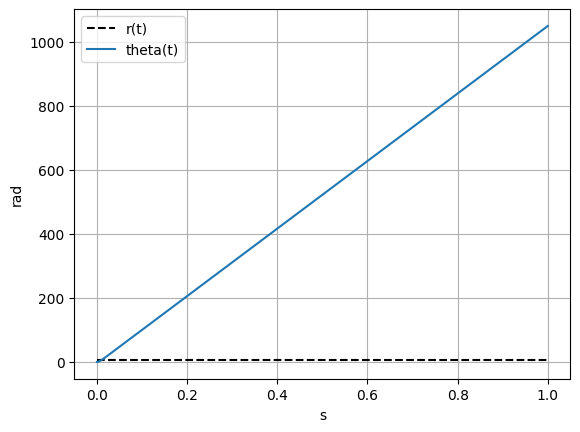

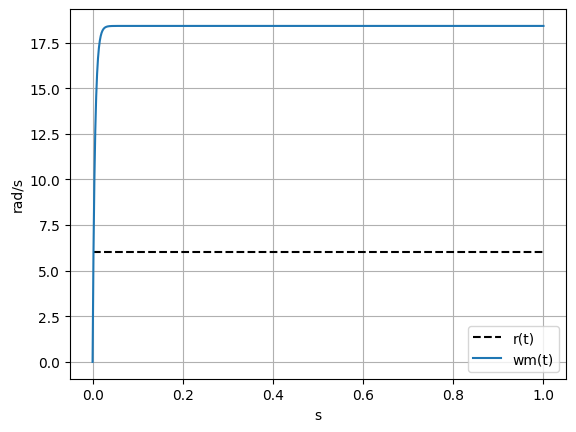

In [177]:
# ================================
# Modelagem por Espaco de Estados
# ================================

Ra = 2.6 #Ohm
La = 0.006245 #H
J = 0.0002
B = 1.9e-3
Ke = 0.31
Kt = Ke
Kte = Kt

# x = [wa, theta]
# wm -> Velocidade (rad/s) do rotor
# theta -> Posicao (rad) do rotor
A = np.array([
    [-(Kte**2)/(J*Ra) - B/J, 0],
    [1, 0]
])

B = np.array([[Kte/(J*Ra)],[0]])

# [wm theta]
C = np.array([[0,1]])

D = 0

print(f'Autovalores de A:\n{np.linalg.eigvals(A)}')

# ==========================
# Resposta Malha aberta
# ==========================

sys = signal.StateSpace(A, B, C, D)
t,y,x = signal.lsim(sys, U=u, T=timeVect)

# Ganho estático de velocidade
Km = x[-1,0]/u[-1]
print(f'Km = {Km} (rad/s)/V')

print(f'rad max: {np.max(y)} rad/s')
print(f'Theta max (graus): {np.max(np.rad2deg(y))}')

plotData(timeVect,u,np.rad2deg(y), ['s','rad'], ['r(t)','theta(t)'])
plotData(timeVect,u,x[:,0], ['s','rad/s'], ['r(t)','wm(t)'])

In [178]:
# ===============================
#  Novo Sistema
# ===============================

# Matriz de Controlabilidade
U = np.concatenate((B, A @ B, np.linalg.matrix_power(A,2)@B), axis=1)
rank_U = np.linalg.matrix_rank(U)
print()
print("\nMatriz de Controlabilidade U:\n", U)
print()
print("Posto da Matriz de Controlabilidade:", rank_U)
print()

# Expandindo as matrizes para incluir o integrador
# e o estado erro
Ahat = np.concatenate((A, np.zeros((A.shape[0],1))), axis=1)
temp = np.concatenate((-C, np.array([[0]])), axis=1)
Ahat = np.concatenate((Ahat, temp), axis=0)
Bhat = np.concatenate((B, np.array([[0]])), axis=0)

del temp

# Ganho de realimentatacao e de integracao
Kvect = ct.acker(Ahat, Bhat, polos)
KI = Kvect[len(Kvect)-1]
K = np.copy(Kvect[0:len(Kvect)-1]).reshape(1,A.shape[0])

print("K:\n", K)
print("KI:\n", KI)

# Sistema aumentado acrecentado do 
# estado erro e ganho dos estados
A00 = A - (B * K)
A01 = B * -KI
A10 = -C
A11 = np.array([[0]])
    
Af = np.concatenate((A00, A01), axis=1)
temp = np.concatenate((A10, A11), axis=1)
Af = np.concatenate((Af, temp), axis=0)

print(f'autovalores de Af = {np.linalg.eigvals(Af)}')

del temp

Bf = np.array([[0],[0],[1]])
Cf = np.concatenate((C, np.array([[0]])), axis=1)
Df = np.array([[0]])



Matriz de Controlabilidade U:
 [[ 5.96153846e+02 -1.15837278e+05  2.25080742e+07]
 [ 0.00000000e+00  5.96153846e+02 -1.15837278e+05]]

Posto da Matriz de Controlabilidade: 2

K:
 [[-0.24541935  1.08425697]]
KI:
 -7.213384394735587
autovalores de Af = [-32.+0.j          -8.+8.38951513j  -8.-8.38951513j]


rad max: 6.27400329185071


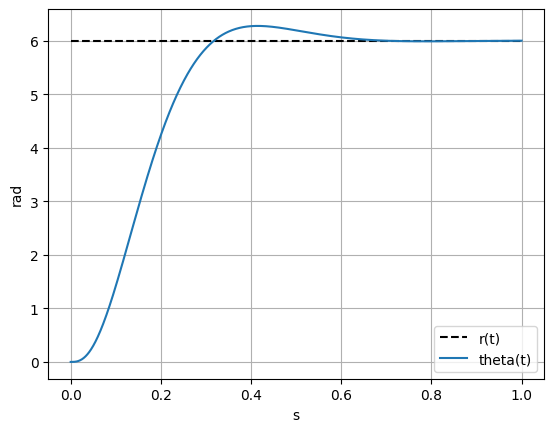

In [179]:
# ==========================
# Resposta coma realimentação e integrador
# ==========================

sys = signal.StateSpace(Af, Bf, Cf, Df)
t,y,x = signal.lsim(sys, U=u, T=timeVect)

print(f'rad max: {np.max(y)}')

plotData(timeVect,u,y, ['s','rad'], ['r(t)','theta(t)'])

# Estados do sistema realimentado

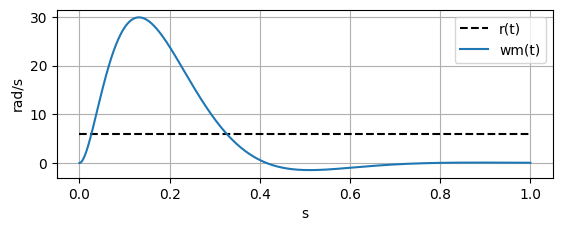

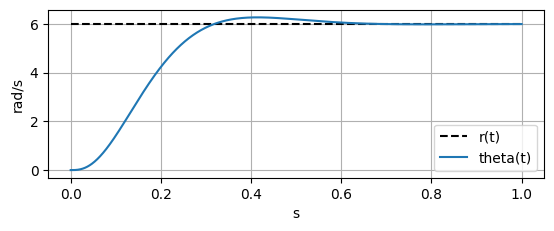

In [180]:
plt.subplot(211)
plotData(t, u, x[:,0], ['s','rad/s'], ['r(t)','wm(t)'])

plt.subplot(212)
plotData(t, u, x[:,1], ['s','rad/s'], ['r(t)','theta(t)'])

# Sinal de Controle

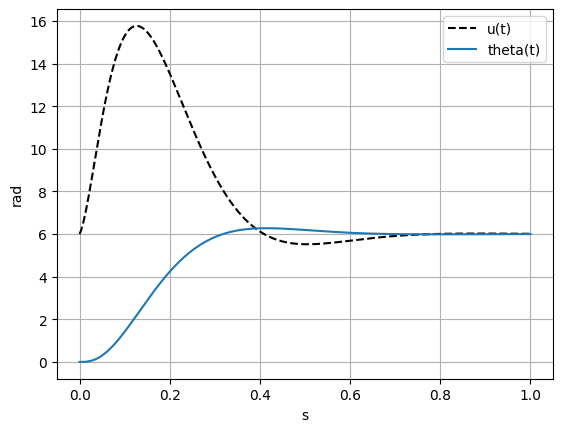

In [181]:
sys = signal.StateSpace(Af, Bf, Cf, Df)
t,y,x = signal.lsim(sys, T=timeVect, U=u)

r = np.copy(u)
u = -np.dot(x, Kvect.T).flatten() + r


plotData(timeVect,u,y, ['s','rad'], ['u(t)','theta(t)'])